<div dir="rtl" align="right" style="text-align: right;">
<h1 dir="rtl" style="text-align: right;">پروژه پایانی داده‌کاوی - گروه ۲۸</h1>
<p dir="rtl" style="text-align: right;"><strong>طبقه‌بندی چندکلاسه با استفاده از روش‌های یادگیری ماشین</strong><br />
رادمهر میرادی - ۶۱۰۳۰۲۲۰۱<br />
مریم تقی‌نسب - ۶۱۰۳۰۲۱۳۲</p>
</div>

<div dir="rtl" align="right" style="text-align: right;">
<h2 dir="rtl" style="text-align: right;">خلاصه</h2>
<p dir="rtl" style="text-align: right;">هدف این نوت‌بوک اجرای یک چرخه کامل داده‌کاوی روی داده اختصاصی گروه ۲۸ است. داده شامل ۱۰۰٬۰۰۰ نمونه و ۳۴ ویژگی است و ستون <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">y</code> یکی از چهار کلاس هدف را نشان می‌دهد. پس از شناخت داده، پاک‌سازی، تبدیل ویژگی زمانی، مدیریت مقادیر گمشده و کدگذاری ویژگی‌های دسته‌ای، سه مدل Logistic Regression، Decision Tree و Random Forest مقایسه می‌شوند. انتخاب ویژگی با استفاده از اهمیت ویژگی‌های Random Forest انجام می‌شود و مدل نهایی با ۲۵ ویژگی آموزش می‌بیند.</p>
<p dir="rtl" style="text-align: right;">نتیجه اجرا نشان می‌دهد Random Forest با ویژگی‌های منتخب بهترین توازن را میان عملکرد کلی و تشخیص کلاس‌های کم‌تعداد دارد: Accuracy برابر ۰٫۶۷۹۴ و Macro F1-score برابر ۰٫۴۹۲۳.</p>
</div>

<div dir="rtl" align="right" style="text-align: right;">
<h2 dir="rtl" style="text-align: right;">۱. زمینه و روش</h2>
<p dir="rtl" style="text-align: right;">متغیر هدف نامتوازن است؛ بنابراین معیار اصلی انتخاب مدل Macro F1-score است و Accuracy، Precision، Recall، Weighted F1-score و ماتریس درهم‌ریختگی نیز گزارش می‌شوند. رویکرد پروژه بدون استفاده از داده خارجی شامل این مراحل است: شناخت داده، پیش‌پردازش، مقایسه سه مدل، انتخاب حداکثر ۲۵ ویژگی و آموزش دوباره مدل‌ها.</p>
<h3 dir="rtl" style="text-align: right;">فرض‌های اصلی</h3>
<ul dir="rtl" style="text-align: right;">
<li dir="rtl" style="text-align: right;">هر ردیف یک نمونه مستقل برای طبقه‌بندی است.</li>
<li dir="rtl" style="text-align: right;">ستون <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">y</code> تنها متغیر هدف است و چهار مقدار ۱ تا ۴ دارد.</li>
<li dir="rtl" style="text-align: right;">تقسیم آموزش و آزمون با <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">random_state=42</code> و به‌صورت stratified انجام می‌شود.</li>
<li dir="rtl" style="text-align: right;">Feature Selection فقط با بخش آموزش انجام می‌شود تا داده آزمون در انتخاب ویژگی اثر نگذارد.</li>
</ul>
</div>

<div dir="rtl" align="right" style="text-align: right;">
<h2 dir="rtl" style="text-align: right;">۲. داده و تحلیل اکتشافی</h2>
<h3 dir="rtl" style="text-align: right;">۲.۱. بارگذاری و ساختار کلی</h3>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)


DATA_PATH = "group_28_train.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

df.head()


Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/radmehrmiradi/.cache/fontconfig
	/Users/radmehrmiradi/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/radmehrmiradi/.cache/fontconfig
	/Users/radmehrmiradi/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/radmehrmiradi/.cache/fontconfig
	/Users/radmehrmiradi/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/radmehrmiradi/.cache/fontconfig
	/Users/radmehrmiradi/.fontconfig



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/radmehrmiradi/.cache/fontconfig
	/Users/radmehrmiradi/.fontconfig


Matplotlib is building the font cache; this may take a moment.


Dataset loaded successfully.
Shape of dataset: (100000, 35)


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source1,32.733738,-96.824097,32.747503,1.241,I-35E N,Dallas,Dallas,TX,75208,US,US/Central,KRBD,2021-09-25 18:53:00,84.0,84.0,28.0,29.30,10.0,7.0,0.0,Fair,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
1,Source1,30.189764,-81.659467,30.190533,0.869,W Beltway N,Jacksonville,Duval,FL,32257,US,US/Eastern,KNIP,2020-10-03 01:53:00,69.0,69.0,63.0,30.03,10.0,14.0,0.0,Cloudy,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2
2,Source1,25.969652,-80.165316,25.988612,1.310,I-95,Miami,Miami-Dade,FL,33179,US,US/Eastern,KHWO,2023-01-29 13:53:00,81.0,81.0,56.0,30.18,10.0,14.0,0.0,Partly Cloudy,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,43.586674,-116.243604,43.589749,0.212,S Orchard St,Boise,Ada,ID,83705,US,US/Mountain,KBOI,2021-11-19 14:53:00,54.0,54.0,64.0,27.05,10.0,8.0,0.0,Cloudy,False,False,True,False,False,False,False,False,Day,Day,Day,Day,2
4,Source1,38.872111,-77.080905,38.872942,0.065,Washington Blvd,Arlington,Arlington,VA,22204,US,US/Eastern,KDCA,2022-12-17 18:52:00,43.0,39.0,47.0,29.86,10.0,7.0,0.0,Cloudy,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

Number of rows: 100000
Number of columns: 35

Column names:
['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   f1      100000 non-null  object 
 1   f2      100000 non-null  float64
 2   f3      100000 non-null  float64
 3   f4      55771 non-null   float64
 4   f5      100000 non-null  float64
 5   f6      99871 non-null   object 
 6   f7      99996 non-null   object 
 7   f8      100000 non-null  object 
 8   f9      100000 non-null  object 
 9   f10     99973 non-null   object 
 10  f11     100000 non-null  object 
 11  f12     99899 non-null   object 
 12  f13     99721 non-null   object 
 13  f14  

In [3]:
target_col = "y"

feature_cols = [col for col in df.columns if col != target_col]

print("Number of feature columns:", len(feature_cols))
print("Target column:", target_col)

X = df[feature_cols]
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

Number of feature columns: 34
Target column: y
X shape: (100000, 34)
y shape: (100000,)


In [4]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nBoolean columns:")
print(bool_cols)

print("\nNumber of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))
print("Number of boolean columns:", len(bool_cols))

Numeric columns:
['f2', 'f3', 'f4', 'f5', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21']

Categorical columns:
['f1', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f22', 'f31', 'f32', 'f33', 'f34']

Boolean columns:
['f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30']

Number of numeric columns: 11
Number of categorical columns: 15
Number of boolean columns: 8


In [5]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
f2,100000.0,36.211780,5.069801,24.603227,33.426451,35.826437,40.085615,49.000560
f3,100000.0,-94.682173,17.403048,-124.445264,-117.215806,-87.745774,-80.344349,-68.291850
f4,55771.0,36.273003,5.280623,24.624287,33.482635,36.205844,40.207482,48.993330
f5,100000.0,0.558330,1.684262,0.000000,0.000000,0.028000,0.461000,97.800003
f15,97887.0,61.638269,18.988815,-50.000000,49.000000,64.000000,76.000000,116.600000
f16,73922.0,58.255471,22.353971,-80.000000,43.000000,62.000000,75.000000,113.000000
f17,97743.0,64.808518,22.778899,2.000000,48.000000,67.000000,84.000000,100.000000
f18,98203.0,29.541269,1.010722,19.760000,29.370000,29.860000,30.030000,58.100000
f19,97727.0,9.088032,2.646401,0.000000,10.000000,10.000000,10.000000,111.000000
f20,92526.0,7.683286,5.290486,0.000000,4.600000,7.000000,10.400000,139.000000


<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۲.۲. توزیع متغیر هدف</h3>
<p dir="rtl" style="text-align: right;">در این بخش تعداد و سهم هر کلاس بررسی می‌شود. نامتوازن بودن کلاس‌ها مستقیماً روی انتخاب معیار ارزیابی و وزن‌دهی مدل‌ها اثر دارد.</p>
</div>

In [6]:
target_counts = df[target_col].value_counts().sort_index()
target_percentages = df[target_col].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_distribution

,count,percentage
y,,
1,779,0.78
2,79725,79.72
3,16843,16.84
4,2653,2.65


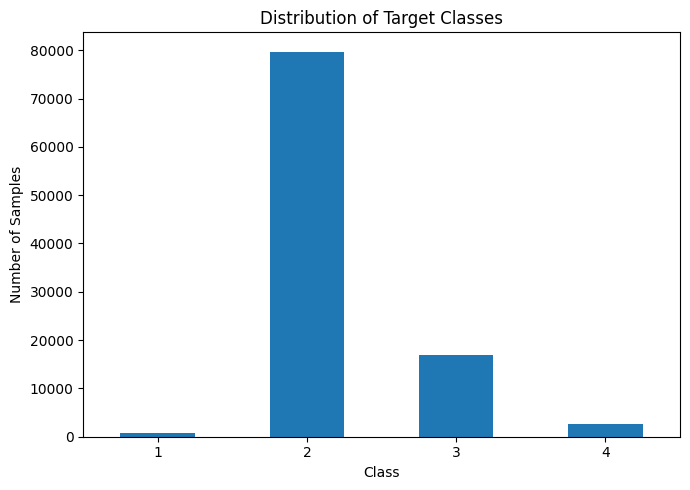

In [7]:
plt.figure(figsize=(7, 5))
target_counts.plot(kind="bar")

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۲.۳. مقادیر گمشده، تکراری و مقادیر یکتا</h3>
</div>

In [8]:
missing_counts = df.isnull().sum()
missing_percentages = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentages.round(2)
})

missing_table = missing_table[missing_table["missing_count"] > 0]
missing_table = missing_table.sort_values(by="missing_count", ascending=False)

missing_table

,missing_count,missing_percentage
f4,44229,44.23
f21,28496,28.50
f16,26078,26.08
f20,7474,7.47
f19,2273,2.27
f17,2257,2.26
f22,2226,2.23
f15,2113,2.11
f18,1797,1.80
f14,1547,1.55


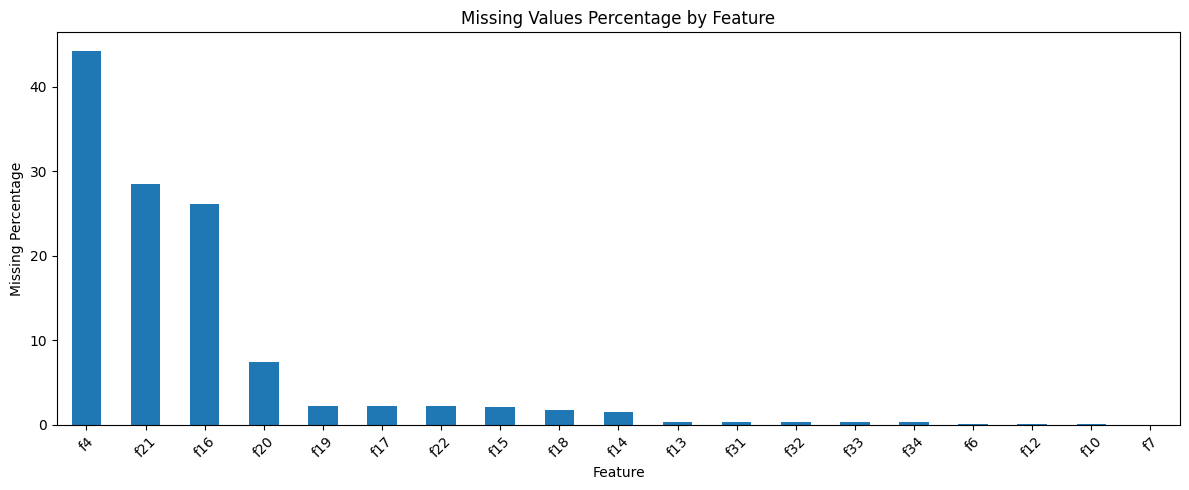

In [9]:
plt.figure(figsize=(12, 5))
missing_table["missing_percentage"].plot(kind="bar")

plt.title("Missing Values Percentage by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print("Number of duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 3), "%")

Number of duplicate rows: 138
Duplicate percentage: 0.138 %


In [11]:
unique_values = pd.DataFrame({
    "unique_count": df.nunique(dropna=False),
    "unique_percentage": (df.nunique(dropna=False) / len(df) * 100).round(2)
})

unique_values = unique_values.sort_values(by="unique_count", ascending=False)

unique_values

,unique_count,unique_percentage
f3,90609,90.61
f2,90544,90.54
f14,78006,78.01
f4,51492,51.49
f10,36813,36.81
f6,32637,32.64
f7,6393,6.39
f5,6115,6.12
f13,1607,1.61
f8,1306,1.31


In [12]:
categorical_unique = pd.DataFrame({
    "unique_count": df[categorical_cols].nunique(dropna=False),
    "unique_percentage": (df[categorical_cols].nunique(dropna=False) / len(df) * 100).round(2)
})

categorical_unique = categorical_unique.sort_values(by="unique_count", ascending=False)

categorical_unique

,unique_count,unique_percentage
f14,78006,78.01
f10,36813,36.81
f6,32637,32.64
f7,6393,6.39
f13,1607,1.61
f8,1306,1.31
f22,82,0.08
f9,49,0.05
f12,5,0.00
f1,3,0.00


In [13]:
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]

print("Constant columns:")
print(constant_cols)

Constant columns:
['f11']


In [14]:
for col in categorical_cols:
    unique_count = df[col].nunique(dropna=False)
    
    if unique_count <= 20:
        print("\nColumn:", col)
        print("Number of unique values:", unique_count)
        print(df[col].value_counts(dropna=False).head(20))


Column: f1
Number of unique values: 3
f1
Source1    55771
Source2    42929
Source3     1300
Name: count, dtype: int64

Column: f11
Number of unique values: 1
f11
US    100000
Name: count, dtype: int64

Column: f12
Number of unique values: 5
f12
US/Eastern     46352
US/Pacific     26695
US/Central     21280
US/Mountain     5572
NaN              101
Name: count, dtype: int64

Column: f31
Number of unique values: 3
f31
Day      69211
Night    30510
NaN        279
Name: count, dtype: int64

Column: f32
Number of unique values: 3
f32
Day      73702
Night    26019
NaN        279
Name: count, dtype: int64

Column: f33
Number of unique values: 3
f33
Day      78659
Night    21062
NaN        279
Name: count, dtype: int64

Column: f34
Number of unique values: 3
f34
Day      82643
Night    17078
NaN        279
Name: count, dtype: int64


In [15]:
for col in bool_cols:
    print("\nColumn:", col)
    print(df[col].value_counts(dropna=False))


Column: f23
f23
False    98797
True      1203
Name: count, dtype: int64

Column: f24
f24
False    99951
True        49
Name: count, dtype: int64

Column: f25
f25
False    88780
True     11220
Name: count, dtype: int64

Column: f26
f26
False    99996
True         4
Name: count, dtype: int64

Column: f27
f27
False    97338
True      2662
Name: count, dtype: int64

Column: f28
f28
False    97199
True      2801
Name: count, dtype: int64

Column: f29
f29
False    99901
True        99
Name: count, dtype: int64

Column: f30
f30
False    85226
True     14774
Name: count, dtype: int64


<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۲.۴. تبدیل و بررسی ویژگی زمانی</h3>
</div>

In [16]:
df["f14_datetime"] = pd.to_datetime(df["f14"], errors="coerce")

print("Original f14 missing values:", df["f14"].isnull().sum())
print("Converted f14_datetime missing values:", df["f14_datetime"].isnull().sum())

df[["f14", "f14_datetime"]].head()

Original f14 missing values: 1547
Converted f14_datetime missing values: 1547


,f14,f14_datetime
0,2021-09-25 18:53:00,2021-09-25 18:53:00
1,2020-10-03 01:53:00,2020-10-03 01:53:00
2,2023-01-29 13:53:00,2023-01-29 13:53:00
3,2021-11-19 14:53:00,2021-11-19 14:53:00
4,2022-12-17 18:52:00,2022-12-17 18:52:00


In [17]:
df["f14_year"] = df["f14_datetime"].dt.year
df["f14_month"] = df["f14_datetime"].dt.month
df["f14_day"] = df["f14_datetime"].dt.day
df["f14_hour"] = df["f14_datetime"].dt.hour
df["f14_dayofweek"] = df["f14_datetime"].dt.dayofweek

df[["f14", "f14_year", "f14_month", "f14_day", "f14_hour", "f14_dayofweek"]].head()

,f14,f14_year,f14_month,f14_day,f14_hour,f14_dayofweek
0,2021-09-25 18:53:00,2021.0,9.0,25.0,18.0,5.0
1,2020-10-03 01:53:00,2020.0,10.0,3.0,1.0,5.0
2,2023-01-29 13:53:00,2023.0,1.0,29.0,13.0,6.0
3,2021-11-19 14:53:00,2021.0,11.0,19.0,14.0,4.0
4,2022-12-17 18:52:00,2022.0,12.0,17.0,18.0,5.0


<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۲.۵. توزیع‌ها، داده‌های پرت و ارتباط با هدف</h3>
<p dir="rtl" style="text-align: right;">برای جلوگیری از خروجی‌های تکراری، نمودارها روی چند ویژگی عددی مهم و دارای الگوی متفاوت متمرکز شده‌اند. بررسی عددی همه ستون‌ها در جدول آمار توصیفی و ماتریس همبستگی حفظ شده است.</p>
</div>

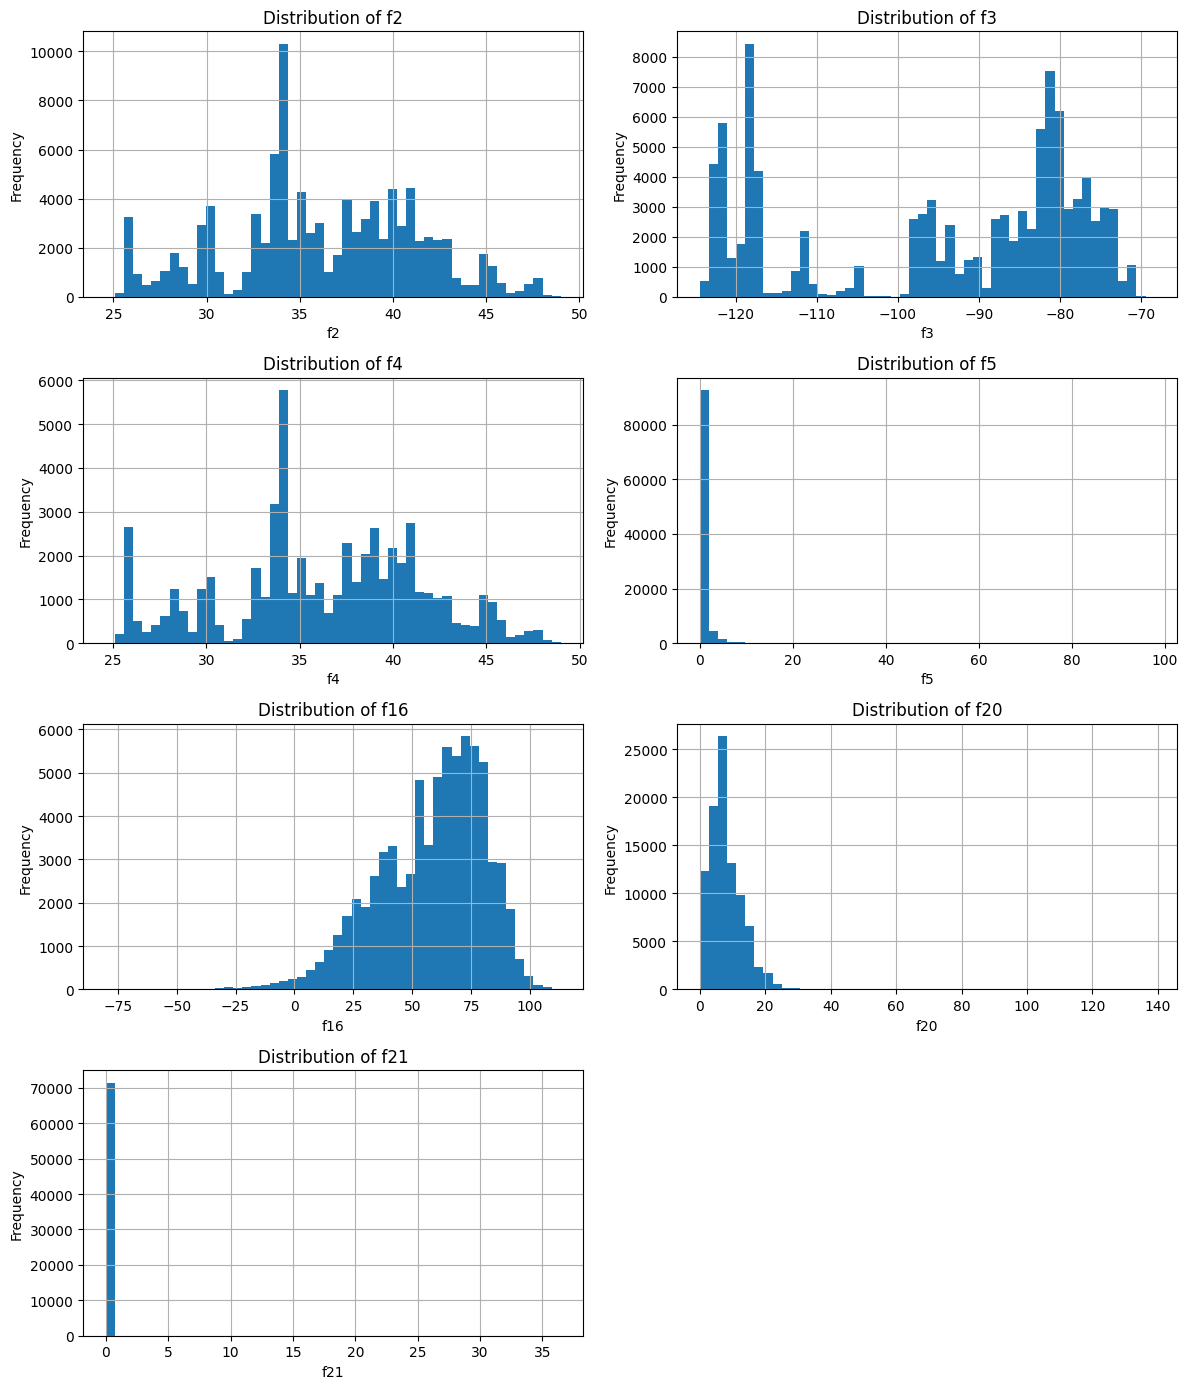

In [18]:
eda_numeric_cols = [
    col for col in ["f2", "f3", "f4", "f5", "f16", "f20", "f21"]
    if col in numeric_cols
]

n_cols = 2
n_rows = int(np.ceil(len(eda_numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, eda_numeric_cols):
    df[col].hist(bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(eda_numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

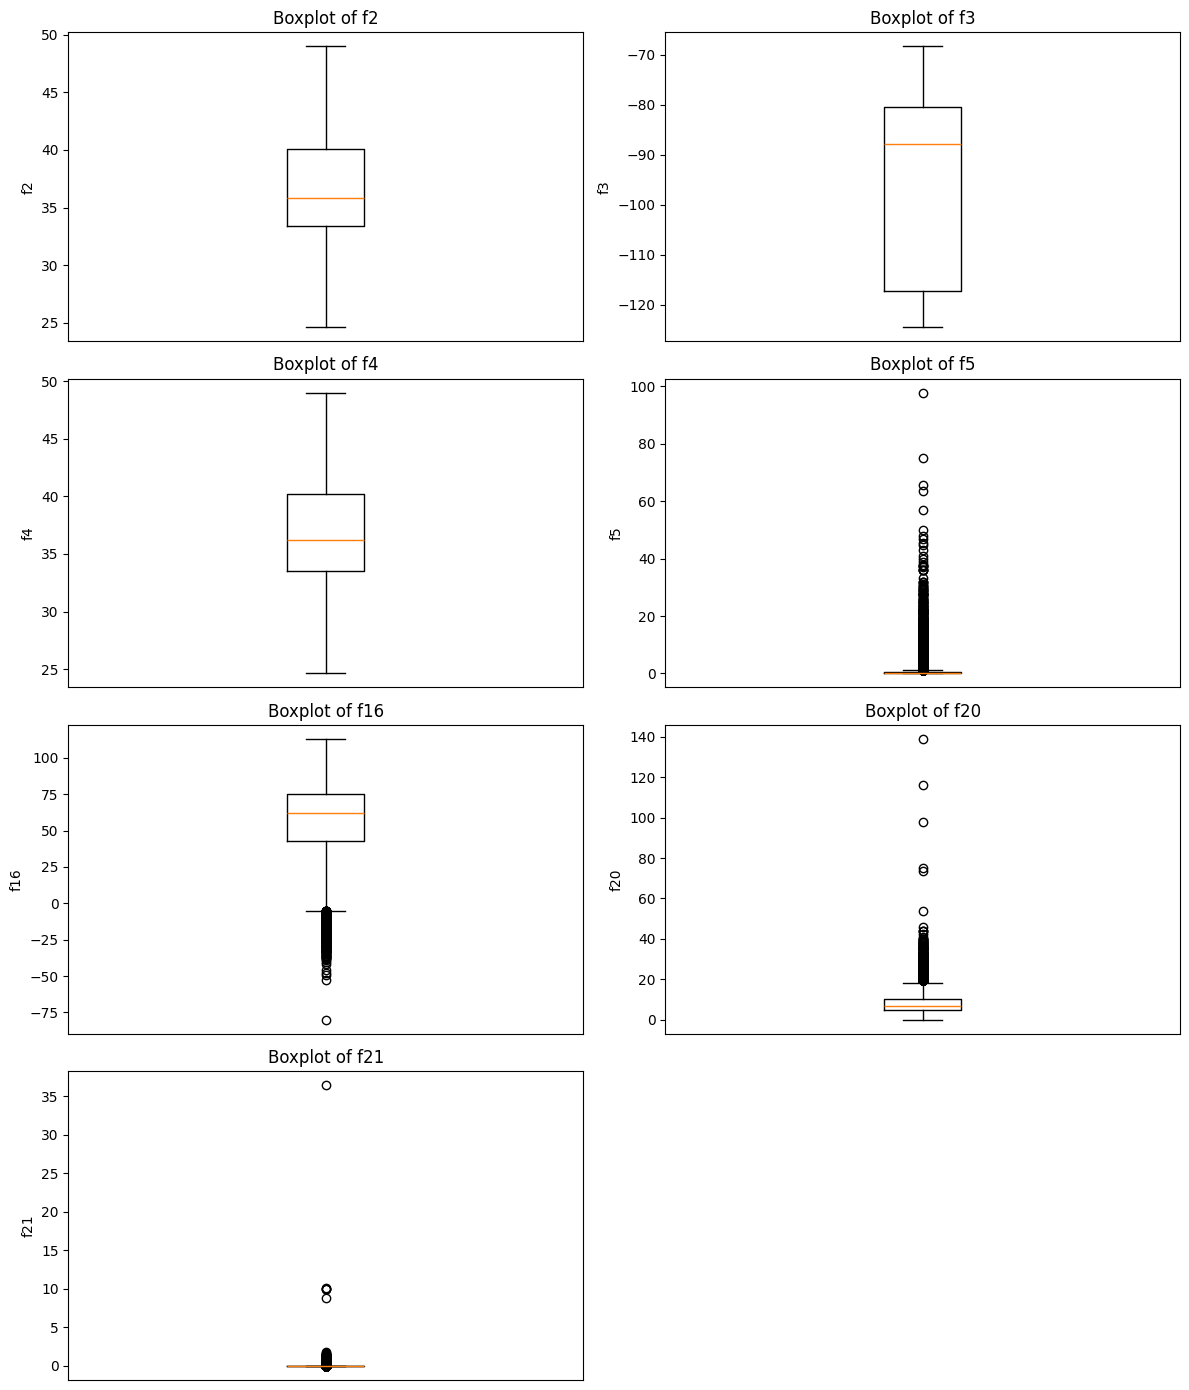

In [19]:
n_cols = 2
n_rows = int(np.ceil(len(eda_numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, eda_numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel(col)
    ax.set_xticks([])

for ax in axes[len(eda_numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
corr_matrix = df[numeric_cols + [target_col]].corr(numeric_only=True)

corr_matrix

,f2,f3,f4,f5,f15,f16,f17,f18,f19,f20,f21,y
f2,1.000000,-0.067145,0.999994,0.068871,-0.442705,-0.480047,0.024380,-0.193532,-0.087675,0.030574,-0.002939,0.067962
f3,-0.067145,1.000000,-0.122190,0.009133,-0.006120,-0.025137,0.174772,0.193801,-0.011118,0.077971,0.016428,0.054572
f4,0.999994,-0.122190,1.000000,0.069316,-0.469228,-0.489592,0.030487,-0.243292,-0.115879,0.012326,-0.005479,0.083417
f5,0.068871,0.009133,0.069316,1.000000,-0.061154,-0.051243,0.015137,-0.101016,-0.043400,0.010217,-0.002867,0.036390
f15,-0.442705,-0.006120,-0.469228,-0.061154,1.000000,0.993757,-0.331110,0.114065,0.217648,0.033187,-0.001475,-0.021940
f16,-0.480047,-0.025137,-0.489592,-0.051243,0.993757,1.000000,-0.312129,0.092822,0.234851,-0.045826,-0.003494,-0.070378
f17,0.024380,0.174772,0.030487,0.015137,-0.331110,-0.312129,1.000000,0.108007,-0.381557,-0.174782,0.054912,0.019924
f18,-0.193532,0.193801,-0.243292,-0.101016,0.114065,0.092822,0.108007,1.000000,0.042270,-0.021305,0.009344,0.045505
f19,-0.087675,-0.011118,-0.115879,-0.043400,0.217648,0.234851,-0.381557,0.042270,1.000000,0.007340,-0.077536,-0.001033
f20,0.030574,0.077971,0.012326,0.010217,0.033187,-0.045826,-0.174782,-0.021305,0.007340,1.000000,0.012711,0.036656


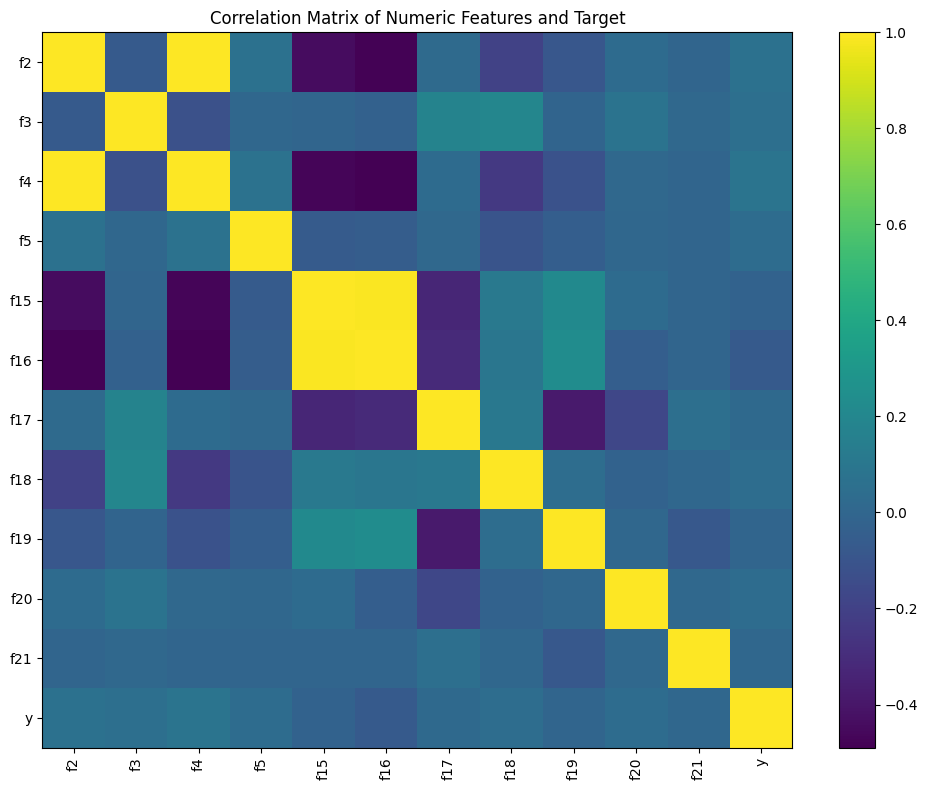

In [21]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix of Numeric Features and Target")

plt.tight_layout()
plt.show()

In [22]:
target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

target_corr

f4     0.083417
f16   -0.070378
f2     0.067962
f3     0.054572
f18    0.045505
f20    0.036656
f5     0.036390
f15   -0.021940
f17    0.019924
f21    0.009826
f19   -0.001033
Name: y, dtype: float64

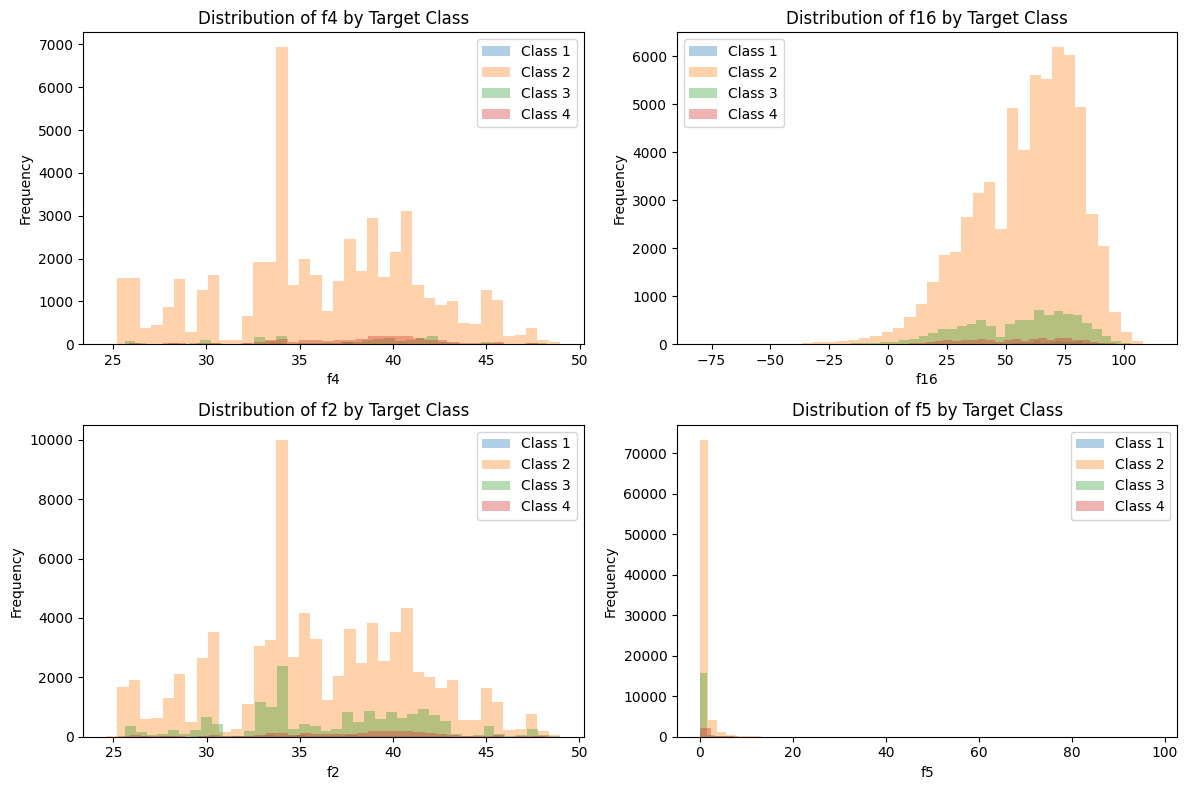

In [23]:
class_comparison_cols = [
    col for col in ["f4", "f16", "f2", "f5"]
    if col in numeric_cols
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, class_comparison_cols):
    for class_value in sorted(df[target_col].unique()):
        subset = df.loc[df[target_col] == class_value, col].dropna()
        ax.hist(subset, bins=40, alpha=0.35, label=f"Class {class_value}")
    ax.set_title(f"Distribution of {col} by Target Class")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()

for ax in axes[len(class_comparison_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۲.۶. ویژگی‌های دسته‌ای و جمع‌بندی EDA</h3>
</div>

In [24]:
for col in categorical_cols:
    print("\n" + "=" * 80)
    print("Column:", col)
    print("Unique values:", df[col].nunique(dropna=False))
    print(df[col].value_counts(dropna=False).head(15))


Column: f1
Unique values: 3
f1
Source1    55771
Source2    42929
Source3     1300
Name: count, dtype: int64

Column: f6
Unique values: 32637
f6
I-95 N     973
I-5 N      926
I-95 S     924
I-10 E     725
I-10 W     675
I-5 S      663
I-80 W     544
I-80 E     439
I-405 N    405
I-75 S     360
I-75 N     357
I-90 E     352
I-90 W     318
I-15 N     315
I-94 W     313
Name: count, dtype: int64

Column: f7
Unique values: 6393
f7
Miami          2356
Houston        2191
Los Angeles    1990
Charlotte      1856
Dallas         1637
Orlando        1441
Austin         1284
Raleigh        1135
Baton Rouge     938
Nashville       927
Atlanta         879
Sacramento      867
San Diego       714
Phoenix         696
Richmond        683
Name: count, dtype: int64

Column: f8
Unique values: 1306
f8
Los Angeles       6866
Miami-Dade        3213
Orange            3157
Harris            2338
Mecklenburg       1957
Dallas            1947
Montgomery        1773
Wake              1545
Travis            1423
S

In [25]:
low_cardinality_cats = [
    col for col in categorical_cols 
    if df[col].nunique(dropna=False) <= 20
]

print("Low-cardinality categorical columns:")
print(low_cardinality_cats)

for col in low_cardinality_cats:
    cross_tab = pd.crosstab(df[col], df[target_col], normalize="index") * 100
    
    print("\n" + "=" * 80)
    print("Column:", col)
    display(cross_tab.round(2))

Low-cardinality categorical columns:
['f1', 'f11', 'f12', 'f31', 'f32', 'f33', 'f34']

Column: f1


y,1,2,3,4
f1,,,,
Source1,0.58,91.28,3.71,4.43
Source2,0.96,65.22,33.40,0.41
Source3,3.23,62.92,33.69,0.15



Column: f11


y,1,2,3,4
f11,,,,
US,0.78,79.72,16.84,2.65



Column: f12


...

y,1,2,3,4
f32,,,,
Day,0.89,79.42,17.41,2.27
Night,0.47,80.51,15.38,3.64



Column: f33


y,1,2,3,4
f33,,,,
Day,0.88,79.50,17.36,2.26
Night,0.42,80.49,15.08,4.01



Column: f34


y,1,2,3,4
f34,,,,
Day,0.87,79.42,17.42,2.30
Night,0.36,81.08,14.30,4.26


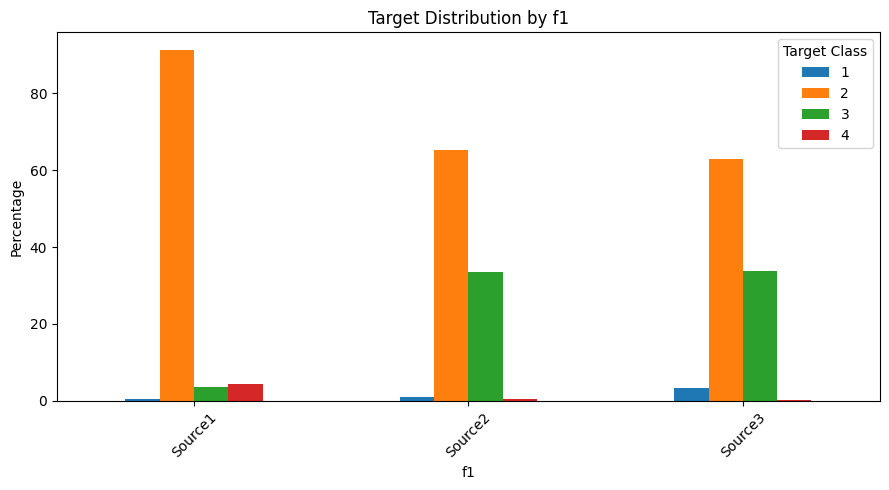

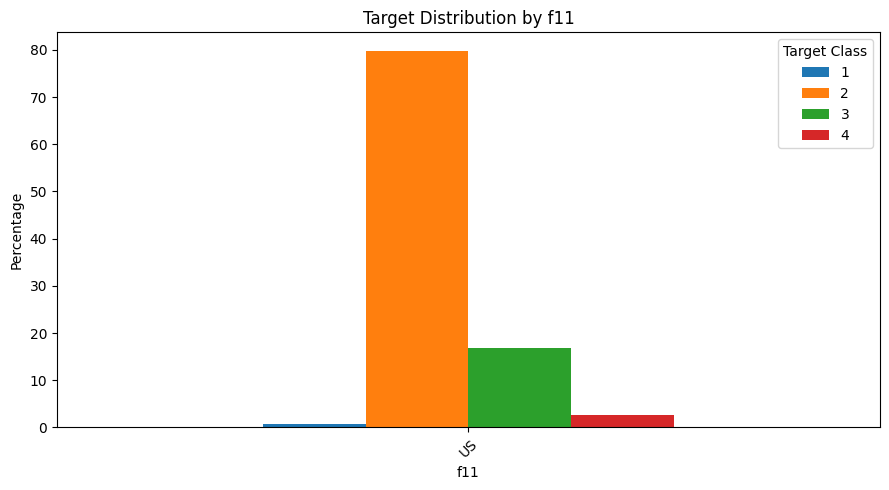

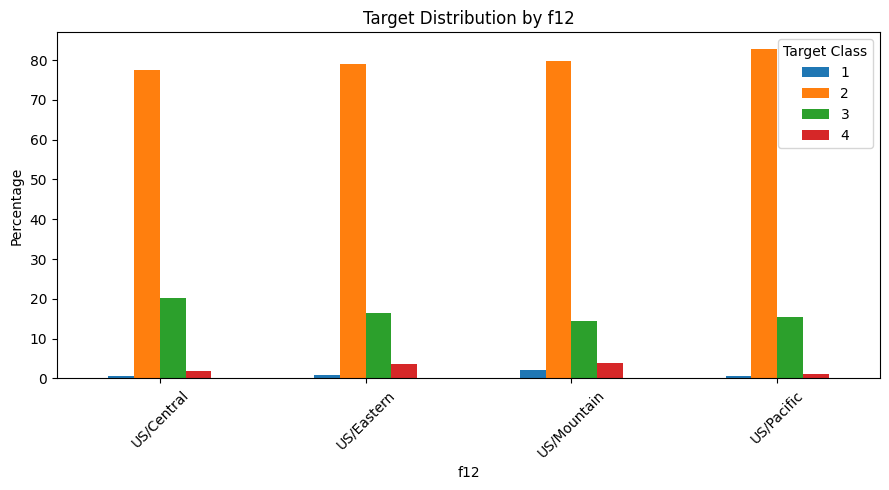

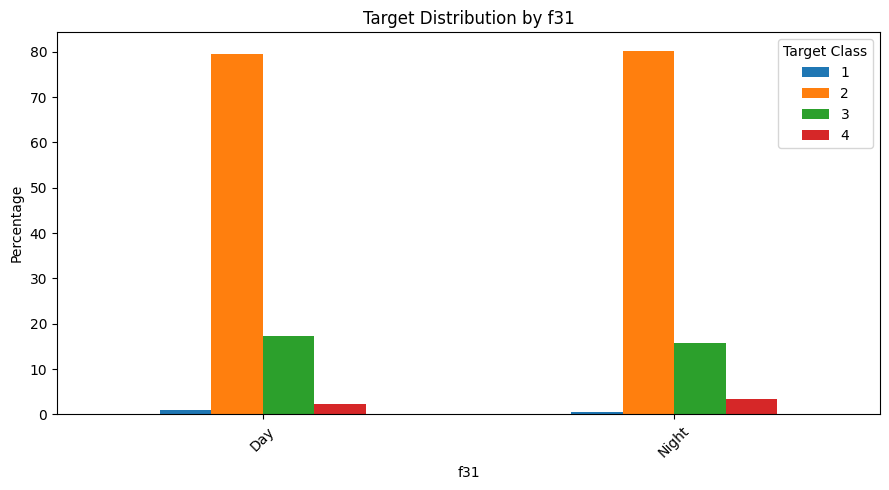

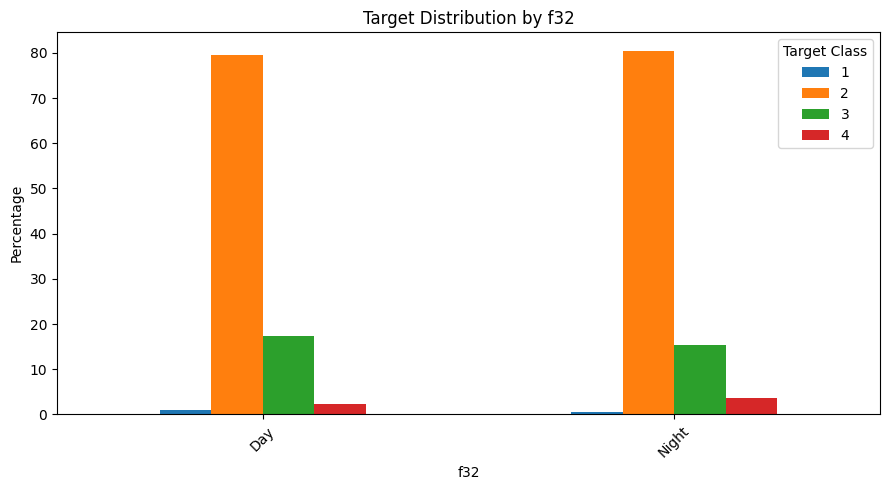

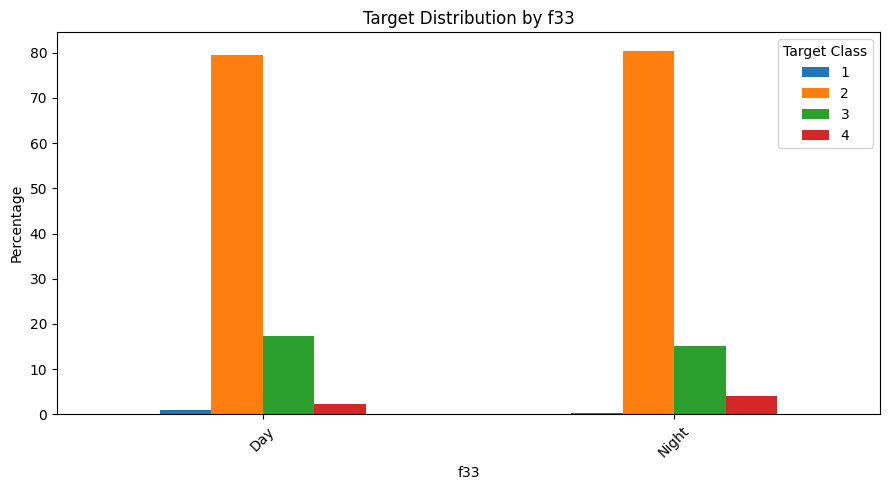

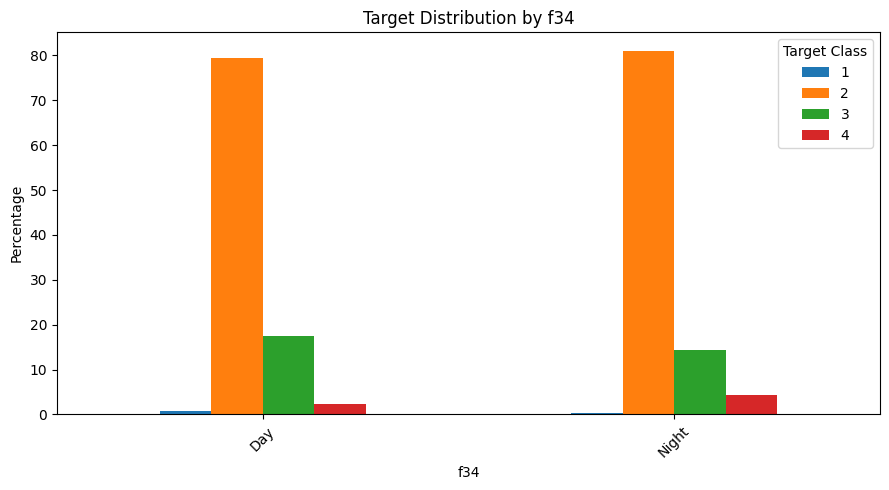

In [26]:
for col in low_cardinality_cats:
    cross_tab = pd.crosstab(df[col], df[target_col], normalize="index") * 100
    
    cross_tab.plot(kind="bar", figsize=(9, 5))
    
    plt.title(f"Target Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.legend(title="Target Class")
    
    plt.tight_layout()
    plt.show()

In [27]:
summary = {
    "number_of_rows": df.shape[0],
    "number_of_columns": len(feature_cols) + 1,
    "number_of_features": len(feature_cols),
    "target_column": target_col,
    "number_of_classes": df[target_col].nunique(),
    "numeric_features": len(numeric_cols),
    "categorical_features": len(categorical_cols),
    "boolean_features": len(bool_cols),
    "total_missing_values": int(df[feature_cols + [target_col]].isnull().sum().sum()),
    "duplicate_rows": int(duplicate_count),
    "constant_columns": constant_cols
}

summary

{'number_of_rows': 100000,
 'number_of_columns': 35,
 'number_of_features': 34,
 'target_column': 'y',
 'number_of_classes': 4,
 'numeric_features': 11,
 'categorical_features': 15,
 'boolean_features': 8,
 'total_missing_values': 120146,
 'duplicate_rows': 138,
 'constant_columns': ['f11']}

In [28]:
target_distribution.to_csv("target_distribution.csv", index=True)
missing_table.to_csv("missing_values_table.csv", index=True)
unique_values.to_csv("unique_values_table.csv", index=True)
target_corr.to_csv("target_correlation.csv", index=True)

print("EDA tables saved successfully.")

EDA tables saved successfully.


<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">جمع‌بندی تحلیل اولیه</h3>
<p dir="rtl" style="text-align: right;">فایل آموزشی شامل ۱۰۰٬۰۰۰ نمونه، ۳۴ ویژگی و ستون هدف <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">y</code> است. مسئله چهارکلاسه است و کلاس‌ها توزیع متوازنی ندارند؛ حدود ۷۹٫۷ درصد نمونه‌ها به کلاس ۲ تعلق دارند، در حالی که سهم کلاس ۱ کمتر از یک درصد است. به همین دلیل، Accuracy به‌تنهایی مبنای مناسبی برای انتخاب مدل نیست و معیار اصلی مقایسه Macro F1-score در نظر گرفته می‌شود.</p>
<p dir="rtl" style="text-align: right;">در داده سه نوع ویژگی عددی، دسته‌ای و بولی وجود دارد. ستون‌های <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">f4</code>، <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">f21</code> و <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">f16</code> بیشترین مقدار گمشده را دارند. برای جلوگیری از حذف بخش بزرگی از داده، این مقادیر در خط لوله پیش‌پردازش جایگزین می‌شوند. ستون <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">f11</code> ثابت است و قدرت تفکیک ندارد. ستون <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">f14</code> نیز تاریخ و زمان را نگه می‌دارد و به ویژگی‌های سال، ماه، روز، ساعت و روز هفته تبدیل می‌شود.</p>
<p dir="rtl" style="text-align: right;">ویژگی‌های دسته‌ای پرکاردینالیتی در مدل پایه مستقیماً One-Hot نمی‌شوند، چون ابعاد داده را به‌شدت افزایش می‌دهند. این تصمیم در ادامه در کنار انتخاب حداکثر ۲۵ ویژگی، پیچیدگی مدل را کنترل می‌کند.</p>
</div>

<div dir="rtl" align="right" style="text-align: right;">
<h2 dir="rtl" style="text-align: right;">۳. پیش‌پردازش</h2>
<h3 dir="rtl" style="text-align: right;">۳.۱. پاک‌سازی و آماده‌سازی اولیه</h3>
</div>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


DATA_PATH = "group_28_train.csv"

df = pd.read_csv(DATA_PATH)

print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (100000, 35)


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source1,32.733738,-96.824097,32.747503,1.241,I-35E N,Dallas,Dallas,TX,75208,US,US/Central,KRBD,2021-09-25 18:53:00,84.0,84.0,28.0,29.30,10.0,7.0,0.0,Fair,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
1,Source1,30.189764,-81.659467,30.190533,0.869,W Beltway N,Jacksonville,Duval,FL,32257,US,US/Eastern,KNIP,2020-10-03 01:53:00,69.0,69.0,63.0,30.03,10.0,14.0,0.0,Cloudy,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2
2,Source1,25.969652,-80.165316,25.988612,1.310,I-95,Miami,Miami-Dade,FL,33179,US,US/Eastern,KHWO,2023-01-29 13:53:00,81.0,81.0,56.0,30.18,10.0,14.0,0.0,Partly Cloudy,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,43.586674,-116.243604,43.589749,0.212,S Orchard St,Boise,Ada,ID,83705,US,US/Mountain,KBOI,2021-11-19 14:53:00,54.0,54.0,64.0,27.05,10.0,8.0,0.0,Cloudy,False,False,True,False,False,False,False,False,Day,Day,Day,Day,2
4,Source1,38.872111,-77.080905,38.872942,0.065,Washington Blvd,Arlington,Arlington,VA,22204,US,US/Eastern,KDCA,2022-12-17 18:52:00,43.0,39.0,47.0,29.86,10.0,7.0,0.0,Cloudy,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2


In [30]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows before removing:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Number of duplicate rows after removing:", df.duplicated().sum())

Number of duplicate rows before removing: 138


Dataset shape after removing duplicates: (99862, 35)


Number of duplicate rows after removing: 0


In [31]:
target_col = "y"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

X shape: (99862, 34)
y shape: (99862,)

Target distribution:
y
1      778
2    79602
3    16829
4     2653
Name: count, dtype: int64


In [32]:
constant_cols = [col for col in X.columns if X[col].nunique(dropna=False) == 1]

print("Constant columns:", constant_cols)

X = X.drop(columns=constant_cols)

print("X shape after dropping constant columns:", X.shape)

Constant columns: ['f11']
X shape after dropping constant columns: (99862, 33)


In [33]:
if "f14" in X.columns:
    X["f14_datetime"] = pd.to_datetime(X["f14"], errors="coerce")
    
    X["f14_year"] = X["f14_datetime"].dt.year
    X["f14_month"] = X["f14_datetime"].dt.month
    X["f14_day"] = X["f14_datetime"].dt.day
    X["f14_hour"] = X["f14_datetime"].dt.hour
    X["f14_dayofweek"] = X["f14_datetime"].dt.dayofweek
    
    X = X.drop(columns=["f14", "f14_datetime"])

print("X shape after date feature extraction:", X.shape)

X.head()

X shape after date feature extraction: (99862, 37)


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f12,f13,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f14_year,f14_month,f14_day,f14_hour,f14_dayofweek
0,Source1,32.733738,-96.824097,32.747503,1.241,I-35E N,Dallas,Dallas,TX,75208,US/Central,KRBD,84.0,84.0,28.0,29.30,10.0,7.0,0.0,Fair,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2021.0,9.0,25.0,18.0,5.0
1,Source1,30.189764,-81.659467,30.190533,0.869,W Beltway N,Jacksonville,Duval,FL,32257,US/Eastern,KNIP,69.0,69.0,63.0,30.03,10.0,14.0,0.0,Cloudy,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2020.0,10.0,3.0,1.0,5.0
2,Source1,25.969652,-80.165316,25.988612,1.310,I-95,Miami,Miami-Dade,FL,33179,US/Eastern,KHWO,81.0,81.0,56.0,30.18,10.0,14.0,0.0,Partly Cloudy,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2023.0,1.0,29.0,13.0,6.0
3,Source1,43.586674,-116.243604,43.589749,0.212,S Orchard St,Boise,Ada,ID,83705,US/Mountain,KBOI,54.0,54.0,64.0,27.05,10.0,8.0,0.0,Cloudy,False,False,True,False,False,False,False,False,Day,Day,Day,Day,2021.0,11.0,19.0,14.0,4.0
4,Source1,38.872111,-77.080905,38.872942,0.065,Washington Blvd,Arlington,Arlington,VA,22204,US/Eastern,KDCA,43.0,39.0,47.0,29.86,10.0,7.0,0.0,Cloudy,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2022.0,12.0,17.0,18.0,5.0


In [34]:
bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()

print("Boolean columns:", bool_cols)

for col in bool_cols:
    X[col] = X[col].astype(int)

print("Boolean columns converted to 0/1.")
X[bool_cols].head()

Boolean columns: ['f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30']
Boolean columns converted to 0/1.


,f23,f24,f25,f26,f27,f28,f29,f30
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0


In [35]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Numeric columns:")
print(numeric_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Categorical columns:")
print(categorical_cols)

Number of numeric columns: 24
Numeric columns:
['f2', 'f3', 'f4', 'f5', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f14_year', 'f14_month', 'f14_day', 'f14_hour', 'f14_dayofweek']

Number of categorical columns: 13
Categorical columns:
['f1', 'f6', 'f7', 'f8', 'f9', 'f10', 'f12', 'f13', 'f22', 'f31', 'f32', 'f33', 'f34']


In [36]:
missing_counts = X.isnull().sum()
missing_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": (missing_counts / len(X) * 100).round(2)
})

missing_table = missing_table[missing_table["missing_count"] > 0]
missing_table = missing_table.sort_values(by="missing_count", ascending=False)

missing_table

,missing_count,missing_percentage
f4,44211,44.27
f21,28472,28.51
f16,26052,26.09
f20,7454,7.46
f19,2252,2.26
f17,2236,2.24
f22,2206,2.21
f15,2092,2.09
f18,1777,1.78
f14_year,1527,1.53


In [37]:
cardinality_table = pd.DataFrame({
    "unique_count": X[categorical_cols].nunique(dropna=False)
}).sort_values(by="unique_count", ascending=False)

cardinality_table

,unique_count
f10,36813
f6,32637
f7,6393
f13,1607
f8,1306
f22,82
f9,49
f12,5
f1,3
f31,3


In [38]:
MAX_CARDINALITY_FOR_ONEHOT = 20

low_cardinality_cats = [
    col for col in categorical_cols
    if X[col].nunique(dropna=False) <= MAX_CARDINALITY_FOR_ONEHOT
]

high_cardinality_cats = [
    col for col in categorical_cols
    if X[col].nunique(dropna=False) > MAX_CARDINALITY_FOR_ONEHOT
]

print("Low-cardinality categorical columns:")
print(low_cardinality_cats)

print("\nHigh-cardinality categorical columns to drop for baseline:")
print(high_cardinality_cats)

Low-cardinality categorical columns:


['f1', 'f12', 'f31', 'f32', 'f33', 'f34']

High-cardinality categorical columns to drop for baseline:
['f6', 'f7', 'f8', 'f9', 'f10', 'f13', 'f22']


In [39]:
X_baseline = X.drop(columns=high_cardinality_cats)

print("Shape before dropping high-cardinality categorical columns:", X.shape)
print("Shape after dropping high-cardinality categorical columns:", X_baseline.shape)

X_baseline.head()

Shape before dropping high-cardinality categorical columns: (99862, 37)
Shape after dropping high-cardinality categorical columns: (99862, 30)


,f1,f2,f3,f4,f5,f12,f15,f16,f17,f18,f19,f20,f21,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f14_year,f14_month,f14_day,f14_hour,f14_dayofweek
0,Source1,32.733738,-96.824097,32.747503,1.241,US/Central,84.0,84.0,28.0,29.30,10.0,7.0,0.0,0,0,0,0,0,0,0,0,Day,Day,Day,Day,2021.0,9.0,25.0,18.0,5.0
1,Source1,30.189764,-81.659467,30.190533,0.869,US/Eastern,69.0,69.0,63.0,30.03,10.0,14.0,0.0,0,0,0,0,0,0,0,0,Night,Night,Night,Night,2020.0,10.0,3.0,1.0,5.0
2,Source1,25.969652,-80.165316,25.988612,1.310,US/Eastern,81.0,81.0,56.0,30.18,10.0,14.0,0.0,0,0,0,0,0,0,0,0,Day,Day,Day,Day,2023.0,1.0,29.0,13.0,6.0
3,Source1,43.586674,-116.243604,43.589749,0.212,US/Mountain,54.0,54.0,64.0,27.05,10.0,8.0,0.0,0,0,1,0,0,0,0,0,Day,Day,Day,Day,2021.0,11.0,19.0,14.0,4.0
4,Source1,38.872111,-77.080905,38.872942,0.065,US/Eastern,43.0,39.0,47.0,29.86,10.0,7.0,0.0,0,0,0,0,0,0,0,0,Night,Night,Night,Night,2022.0,12.0,17.0,18.0,5.0


<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۳.۲. تقسیم داده و خط لوله تبدیل‌ها</h3>
<p dir="rtl" style="text-align: right;">تمام تبدیل‌هایی که نیاز به یادگیری پارامتر دارند داخل Pipeline قرار می‌گیرند. در نتیجه، میانه، میانگین و انحراف معیار و دسته‌های One-Hot فقط از داده آموزش به دست می‌آیند.</p>
</div>

In [40]:
numeric_cols_baseline = X_baseline.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_baseline = X_baseline.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns for baseline:")
print(numeric_cols_baseline)

print("\nCategorical columns for baseline:")
print(categorical_cols_baseline)

print("\nNumber of numeric columns:", len(numeric_cols_baseline))
print("Number of categorical columns:", len(categorical_cols_baseline))

Numeric columns for baseline:
['f2', 'f3', 'f4', 'f5', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f14_year', 'f14_month', 'f14_day', 'f14_hour', 'f14_dayofweek']

Categorical columns for baseline:
['f1', 'f12', 'f31', 'f32', 'f33', 'f34']

Number of numeric columns: 24
Number of categorical columns: 6


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

X_train shape: (79889, 30)
X_test shape: (19973, 30)

Train target distribution:
y
1     0.779832
2    79.711850
3    16.852132
4     2.656185
Name: proportion, dtype: float64

Test target distribution:
y
1     0.776048
2    79.712612
3    16.852751
4     2.658589
Name: proportion, dtype: float64


In [42]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols_baseline),
        ("cat", categorical_transformer, categorical_cols_baseline)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [43]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (79889, 44)
Processed X_test shape: (19973, 44)


In [44]:
numeric_feature_names = numeric_cols_baseline

onehot_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]

categorical_feature_names = onehot_encoder.get_feature_names_out(categorical_cols_baseline).tolist()

processed_feature_names = numeric_feature_names + categorical_feature_names

print("Number of processed features:", len(processed_feature_names))
print("First 50 processed feature names:")
print(processed_feature_names[:50])

Number of processed features: 44
First 50 processed feature names:
['f2', 'f3', 'f4', 'f5', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f14_year', 'f14_month', 'f14_day', 'f14_hour', 'f14_dayofweek', 'f1_Source1', 'f1_Source2', 'f1_Source3', 'f12_US/Central', 'f12_US/Eastern', 'f12_US/Mountain', 'f12_US/Pacific', 'f12_Unknown', 'f31_Day', 'f31_Night', 'f31_Unknown', 'f32_Day', 'f32_Night', 'f32_Unknown', 'f33_Day', 'f33_Night', 'f33_Unknown', 'f34_Day', 'f34_Night', 'f34_Unknown']


In [45]:
cleaned_baseline_df = X_baseline.copy()
cleaned_baseline_df[target_col] = y

cleaned_baseline_df.to_csv("group_28_cleaned_baseline.csv", index=False)

print("Cleaned baseline dataset saved as group_28_cleaned_baseline.csv")
print("Saved dataset shape:", cleaned_baseline_df.shape)

Cleaned baseline dataset saved as group_28_cleaned_baseline.csv
Saved dataset shape: (99862, 31)


In [46]:
preprocessing_summary = {
    "original_shape": df.shape,
    "duplicates_removed": int(duplicate_count),
    "constant_columns_removed": constant_cols,
    "date_column_processed": "f14",
    "high_cardinality_categorical_removed_for_baseline": high_cardinality_cats,
    "low_cardinality_categorical_encoded": low_cardinality_cats,
    "numeric_columns_used": numeric_cols_baseline,
    "categorical_columns_used": categorical_cols_baseline,
    "baseline_X_shape": X_baseline.shape,
    "train_shape": X_train.shape,
    "test_shape": X_test.shape,
    "processed_train_shape": X_train_processed.shape,
    "processed_test_shape": X_test_processed.shape
}

preprocessing_summary

{'original_shape': (99862, 35),
 'duplicates_removed': 138,
 'constant_columns_removed': ['f11'],
 'date_column_processed': 'f14',
 'high_cardinality_categorical_removed_for_baseline': ['f6',
  'f7',
  'f8',
  'f9',
  'f10',
  'f13',
  'f22'],
 'low_cardinality_categorical_encoded': ['f1',
  'f12',
  'f31',
  'f32',
  'f33',
  'f34'],
 'numeric_columns_used': ['f2',
  'f3',
  'f4',
  'f5',
  'f15',
  'f16',
  'f17',
  'f18',
  'f19',
  'f20',
  'f21',
  'f23',
  'f24',
  'f25',
  'f26',
  'f27',
  'f28',
  'f29',
  'f30',
  'f14_year',
  'f14_month',
  'f14_day',
  'f14_hour',
  'f14_dayofweek'],
 'categorical_columns_used': ['f1', 'f12', 'f31', 'f32', 'f33', 'f34'],
 'baseline_X_shape': (99862, 30),
 'train_shape': (79889, 30),
 'test_shape': (19973, 30),
 'processed_train_shape': (79889, 44),
 'processed_test_shape': (19973, 44)}

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">جمع‌بندی پیش‌پردازش</h3>
<p dir="rtl" style="text-align: right;">ابتدا ۱۳۸ ردیف کاملاً تکراری حذف شد و تعداد نمونه‌ها به ۹۹٬۸۶۲ رسید. ستون ثابت <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">f11</code> کنار گذاشته شد و <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">f14</code> به پنج ویژگی زمانی تبدیل شد. مقادیر بولی به صفر و یک تبدیل شدند. جایگزینی مقادیر گمشده، استانداردسازی و One-Hot Encoding داخل Pipeline انجام می‌شود تا پارامترهای پیش‌پردازش فقط از بخش آموزش یاد گرفته شوند.</p>
<p dir="rtl" style="text-align: right;">برای ویژگی‌های عددی از میانه استفاده شده است، چون بعضی ستون‌ها توزیع کشیده و داده پرت دارند. برای ویژگی‌های دسته‌ای نیز مقدار <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">Unknown</code> جایگزین مقادیر گمشده می‌شود. تقسیم آموزش و آزمون به‌صورت stratified و با نسبت ۸۰ به ۲۰ انجام شده تا سهم کلاس‌ها در دو بخش ثابت بماند.</p>
</div>

<div dir="rtl" align="right" style="text-align: right;">
<h2 dir="rtl" style="text-align: right;">۴. آموزش و ارزیابی مدل‌ها</h2>
<h3 dir="rtl" style="text-align: right;">۴.۱. معیارهای ارزیابی و تابع مشترک</h3>
</div>

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    print("=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    
    precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    results = {
        "model": model_name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }
    
    return results, y_pred

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۴.۲. سه مدل پایه</h3>
</div>

Training model: Logistic Regression



Classification Report:
              precision    recall  f1-score   support

           1       0.04      0.70      0.07       155
           2       0.94      0.33      0.49     15921
           3       0.39      0.75      0.51      3366
           4       0.08      0.72      0.14       531

    accuracy                           0.41     19973
   macro avg       0.36      0.63      0.30     19973
weighted avg       0.82      0.41      0.48     19973


Confusion Matrix:
[[ 109   19    4   23]
 [2540 5263 3871 4247]
 [ 308  220 2516  322]
 [  44   78   27  382]]


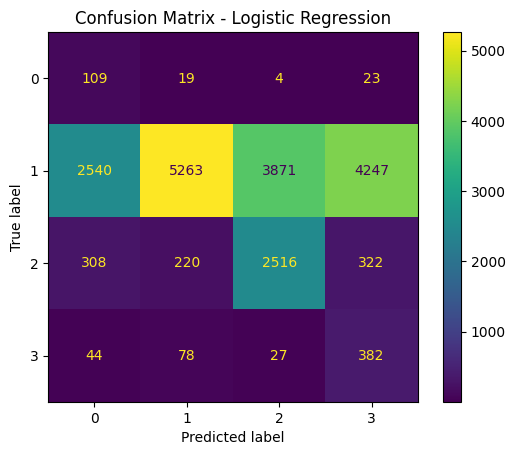

In [48]:
logistic_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_results, logistic_pred = evaluate_model(
    model_name="Logistic Regression",
    model=logistic_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

Training model: Decision Tree



Classification Report:
              precision    recall  f1-score   support

           1       0.22      0.93      0.35       155
           2       0.97      0.55      0.70     15921
           3       0.42      0.81      0.55      3366
           4       0.11      0.73      0.18       531

    accuracy                           0.60     19973
   macro avg       0.43      0.75      0.45     19973
weighted avg       0.84      0.60      0.66     19973


Confusion Matrix:
[[ 144    2    5    4]
 [ 388 8787 3772 2974]
 [ 124  218 2729  295]
 [  13   92   41  385]]


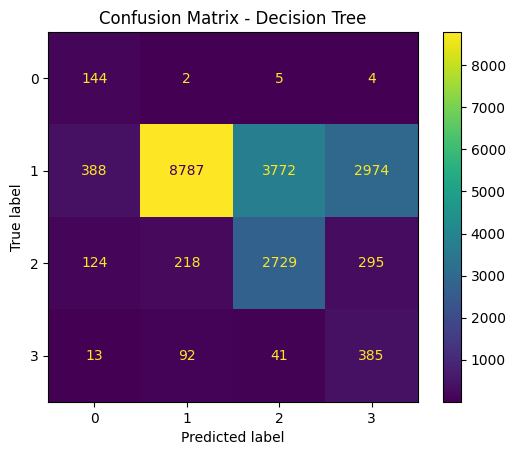

In [49]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_results, decision_tree_pred = evaluate_model(
    model_name="Decision Tree",
    model=decision_tree_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

Training model: Random Forest



Classification Report:
              precision    recall  f1-score   support

           1       0.24      0.94      0.38       155
           2       0.96      0.64      0.77     15921
           3       0.42      0.82      0.56      3366
           4       0.15      0.62      0.24       531

    accuracy                           0.68     19973
   macro avg       0.44      0.75      0.49     19973
weighted avg       0.84      0.68      0.72     19973


Confusion Matrix:
[[  145     1     4     5]
 [  337 10268  3710  1606]
 [  122   252  2748   244]
 [    7   156    41   327]]


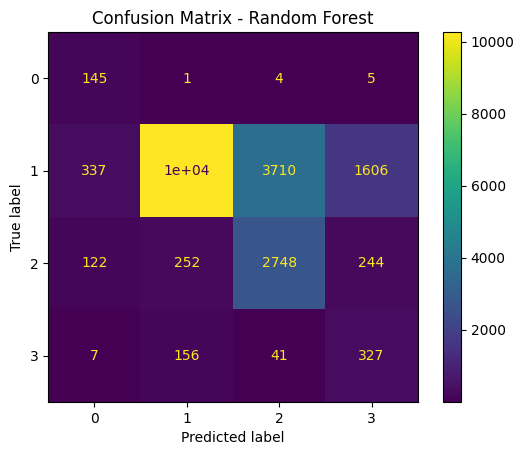

In [50]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

random_forest_results, random_forest_pred = evaluate_model(
    model_name="Random Forest",
    model=random_forest_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۴.۳. مقایسه مدل‌ها</h3>
</div>

In [51]:
all_results = [
    logistic_results,
    decision_tree_results,
    random_forest_results
]

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(by="f1_macro", ascending=False)

results_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
2,Random Forest,0.675312,0.442861,0.753159,0.487159,0.843632,0.675312,0.718651
1,Decision Tree,0.603064,0.425760,0.754187,0.446579,0.844509,0.603064,0.660289
0,Logistic Regression,0.414059,0.362083,0.625167,0.302931,0.820232,0.414059,0.481141


In [52]:
results_df.to_csv("model_comparison_baseline.csv", index=False)

print("Model comparison table saved as model_comparison_baseline.csv")

Model comparison table saved as model_comparison_baseline.csv


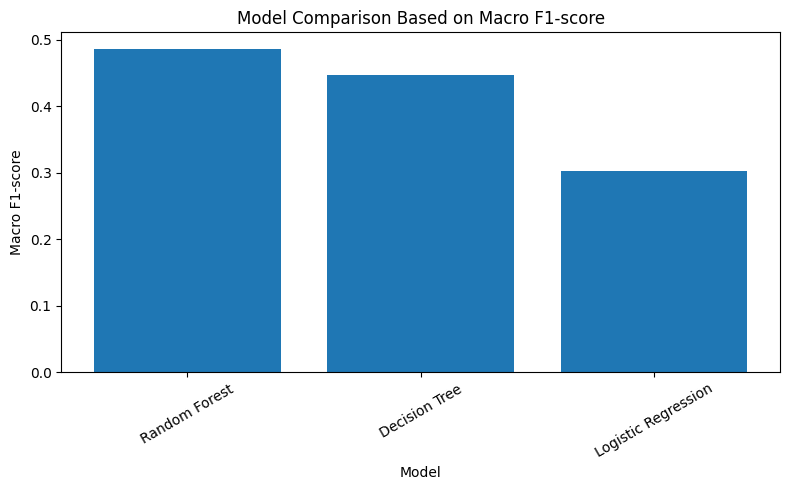

In [53]:
plt.figure(figsize=(8, 5))

plt.bar(results_df["model"], results_df["f1_macro"])

plt.title("Model Comparison Based on Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

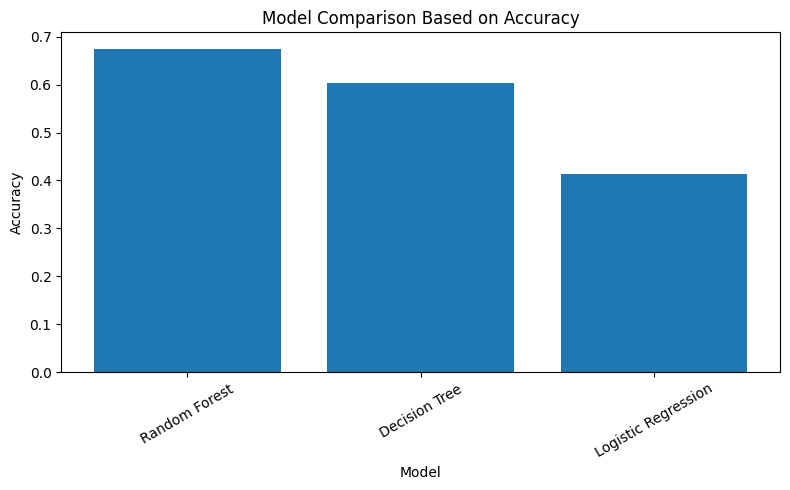

In [54]:
plt.figure(figsize=(8, 5))

plt.bar(results_df["model"], results_df["accuracy"])

plt.title("Model Comparison Based on Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">برداشت از مقایسه اولیه مدل‌ها</h3>
<p dir="rtl" style="text-align: right;">سه مدل Logistic Regression، Decision Tree و Random Forest با تنظیمات ثابت و وزن‌دهی متوازن کلاس‌ها آموزش داده شدند. Logistic Regression نقش خط پایه ساده و تفسیرپذیر را دارد؛ Decision Tree روابط غیرخطی را با ساختاری قابل‌فهم بررسی می‌کند؛ و Random Forest با تجمیع چند درخت، واریانس مدل را کاهش می‌دهد.</p>
<p dir="rtl" style="text-align: right;">در داده آزمون، Random Forest با Accuracy برابر ۰٫۶۷۵۳ و Macro F1-score برابر ۰٫۴۸۷۲ بهترین نتیجه اولیه را به دست آورد. Decision Tree در رتبه بعد قرار گرفت و Logistic Regression ضعیف‌تر بود. فاصله Accuracy و Macro F1-score نشان می‌دهد که عملکرد مناسب روی کلاس غالب الزاماً به معنای عملکرد یکسان روی کلاس‌های کم‌تعداد نیست.</p>
</div>

<div dir="rtl" align="right" style="text-align: right;">
<h2 dir="rtl" style="text-align: right;">۵. انتخاب ویژگی و مدل نهایی</h2>
<h3 dir="rtl" style="text-align: right;">۵.۱. استخراج و تجمیع اهمیت ویژگی‌ها</h3>
</div>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [56]:
trained_preprocessor = random_forest_model.named_steps["preprocessor"]
trained_classifier = random_forest_model.named_steps["classifier"]

processed_feature_names = trained_preprocessor.get_feature_names_out()

feature_importances = trained_classifier.feature_importances_

importance_df = pd.DataFrame({
    "processed_feature": processed_feature_names,
    "importance": feature_importances
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_df.head(30)

,processed_feature,importance
19,num__f14_year,0.180940
3,num__f5,0.156121
24,cat__f1_Source1,0.078995
2,num__f4,0.069581
25,cat__f1_Source2,0.065810
5,num__f16,0.053065
1,num__f3,0.047320
20,num__f14_month,0.044084
0,num__f2,0.042179
18,num__f30,0.035643


In [57]:
def get_original_feature_name(processed_name):
    if processed_name.startswith("num__"):
        return processed_name.replace("num__", "")
    
    if processed_name.startswith("cat__"):
        name = processed_name.replace("cat__", "")
        
        for col in categorical_cols_baseline:
            if name.startswith(col + "_"):
                return col
        
        return name
    
    return processed_name


importance_df["original_feature"] = importance_df["processed_feature"].apply(get_original_feature_name)

importance_df.head(30)

,processed_feature,importance,original_feature
19,num__f14_year,0.180940,f14_year
3,num__f5,0.156121,f5
24,cat__f1_Source1,0.078995,f1
2,num__f4,0.069581,f4
25,cat__f1_Source2,0.065810,f1
5,num__f16,0.053065,f16
1,num__f3,0.047320,f3
20,num__f14_month,0.044084,f14_month
0,num__f2,0.042179,f2
18,num__f30,0.035643,f30


In [58]:
original_importance_df = (
    importance_df
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values(by="importance", ascending=False)
)

original_importance_df

,original_feature,importance
6,f14_year,0.180940
29,f5,0.156121
0,f1,0.146589
28,f4,0.069581
8,f16,0.053065
22,f3,0.047320
5,f14_month,0.044084
12,f2,0.042179
23,f30,0.035643
10,f18,0.032847


In [59]:
TOP_K_FEATURES = 25

selected_features = original_importance_df.head(TOP_K_FEATURES)["original_feature"].tolist()

print("Selected features:")
print(selected_features)

print("\nNumber of selected features:", len(selected_features))

Selected features:
['f14_year', 'f5', 'f1', 'f4', 'f16', 'f3', 'f14_month', 'f2', 'f30', 'f18', 'f15', 'f14_hour', 'f12', 'f17', 'f14_day', 'f20', 'f25', 'f14_dayofweek', 'f34', 'f33', 'f19', 'f31', 'f32', 'f28', 'f21']

Number of selected features: 25


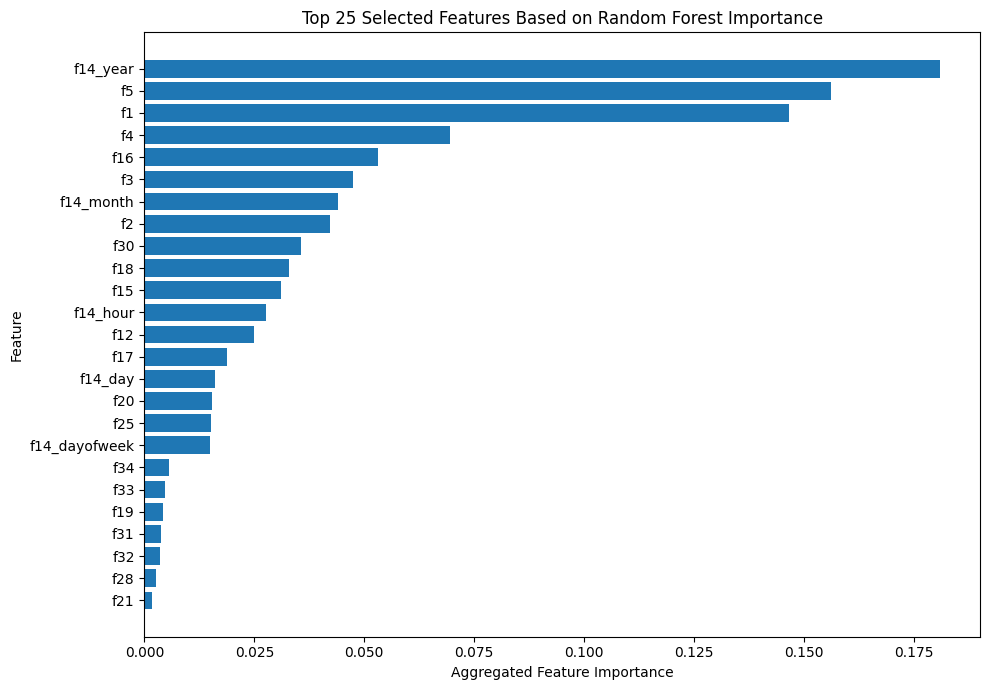

In [60]:
top_features_df = original_importance_df.head(TOP_K_FEATURES)

plt.figure(figsize=(10, 7))

plt.barh(top_features_df["original_feature"][::-1], top_features_df["importance"][::-1])

plt.title("Top 25 Selected Features Based on Random Forest Importance")
plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۵.۲. ساخت داده ۲۵ ویژگی و آموزش دوباره</h3>
</div>

In [61]:
X_selected = X_baseline[selected_features].copy()

print("Shape of selected feature dataset:", X_selected.shape)
X_selected.head()

Shape of selected feature dataset: (99862, 25)


,f14_year,f5,f1,f4,f16,f3,f14_month,f2,f30,f18,f15,f14_hour,f12,f17,f14_day,f20,f25,f14_dayofweek,f34,f33,f19,f31,f32,f28,f21
0,2021.0,1.241,Source1,32.747503,84.0,-96.824097,9.0,32.733738,0,29.30,84.0,18.0,US/Central,28.0,25.0,7.0,0,5.0,Day,Day,10.0,Day,Day,0,0.0
1,2020.0,0.869,Source1,30.190533,69.0,-81.659467,10.0,30.189764,0,30.03,69.0,1.0,US/Eastern,63.0,3.0,14.0,0,5.0,Night,Night,10.0,Night,Night,0,0.0
2,2023.0,1.310,Source1,25.988612,81.0,-80.165316,1.0,25.969652,0,30.18,81.0,13.0,US/Eastern,56.0,29.0,14.0,0,6.0,Day,Day,10.0,Day,Day,0,0.0
3,2021.0,0.212,Source1,43.589749,54.0,-116.243604,11.0,43.586674,0,27.05,54.0,14.0,US/Mountain,64.0,19.0,8.0,1,4.0,Day,Day,10.0,Day,Day,0,0.0
4,2022.0,0.065,Source1,38.872942,39.0,-77.080905,12.0,38.872111,0,29.86,43.0,18.0,US/Eastern,47.0,17.0,7.0,0,5.0,Night,Night,10.0,Night,Night,0,0.0


In [62]:
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

print("\nTrain target distribution:")
print(y_train_selected.value_counts(normalize=True).sort_index() * 100)

print("\nTest target distribution:")
print(y_test_selected.value_counts(normalize=True).sort_index() * 100)

X_train_selected shape: (79889, 25)
X_test_selected shape: (19973, 25)

Train target distribution:
y
1     0.779832
2    79.711850
3    16.852132
4     2.656185
Name: proportion, dtype: float64

Test target distribution:
y
1     0.776048
2    79.712612
3    16.852751
4     2.658589
Name: proportion, dtype: float64


In [63]:
numeric_cols_selected = X_selected.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_selected = X_selected.select_dtypes(include=["object"]).columns.tolist()

print("Numeric selected columns:")
print(numeric_cols_selected)

print("\nCategorical selected columns:")
print(categorical_cols_selected)

print("\nNumber of numeric selected columns:", len(numeric_cols_selected))
print("Number of categorical selected columns:", len(categorical_cols_selected))

Numeric selected columns:
['f14_year', 'f5', 'f4', 'f16', 'f3', 'f14_month', 'f2', 'f30', 'f18', 'f15', 'f14_hour', 'f17', 'f14_day', 'f20', 'f25', 'f14_dayofweek', 'f19', 'f28', 'f21']

Categorical selected columns:
['f1', 'f12', 'f34', 'f33', 'f31', 'f32']

Number of numeric selected columns: 19
Number of categorical selected columns: 6


In [64]:
numeric_transformer_selected = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_selected = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_selected = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_selected, numeric_cols_selected),
        ("cat", categorical_transformer_selected, categorical_cols_selected)
    ]
)

print("Selected-feature preprocessor created successfully.")

Selected-feature preprocessor created successfully.


In [65]:
def evaluate_selected_model(model_name, model, X_train, X_test, y_train, y_test):
    print("=" * 80)
    print(f"Training model with selected features: {model_name}")
    print("=" * 80)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    
    precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name} with Selected Features")
    plt.show()
    
    results = {
        "model": model_name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }
    
    return results, y_pred

Training model with selected features: Logistic Regression Selected



Classification Report:
              precision    recall  f1-score   support

           1       0.04      0.72      0.07       155
           2       0.94      0.33      0.49     15921
           3       0.39      0.75      0.51      3366
           4       0.08      0.72      0.14       531

    accuracy                           0.41     19973
   macro avg       0.36      0.63      0.30     19973
weighted avg       0.82      0.41      0.48     19973


Confusion Matrix:
[[ 111   17    4   23]
 [2567 5217 3892 4245]
 [ 307  224 2511  324]
 [  45   78   27  381]]


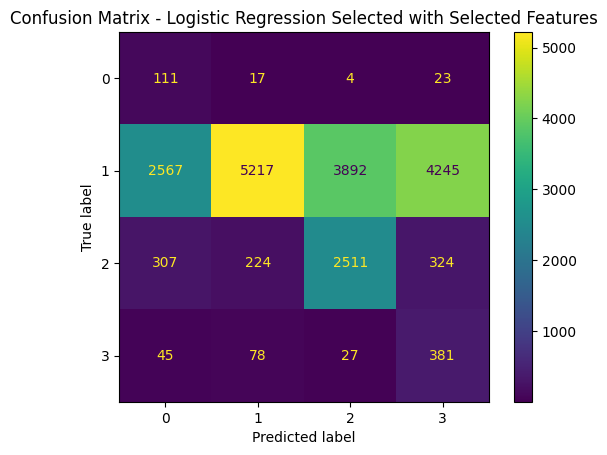

In [66]:
logistic_selected_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_selected)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_selected_results, logistic_selected_pred = evaluate_selected_model(
    model_name="Logistic Regression Selected",
    model=logistic_selected_model,
    X_train=X_train_selected,
    X_test=X_test_selected,
    y_train=y_train_selected,
    y_test=y_test_selected
)

Training model with selected features: Decision Tree Selected



Classification Report:
              precision    recall  f1-score   support

           1       0.21      0.93      0.34       155
           2       0.96      0.56      0.71     15921
           3       0.42      0.80      0.55      3366
           4       0.10      0.72      0.18       531

    accuracy                           0.61     19973
   macro avg       0.42      0.75      0.45     19973
weighted avg       0.84      0.61      0.66     19973


Confusion Matrix:
[[ 144    2    5    4]
 [ 408 8877 3652 2984]
 [ 131  241 2699  295]
 [  13   93   41  384]]


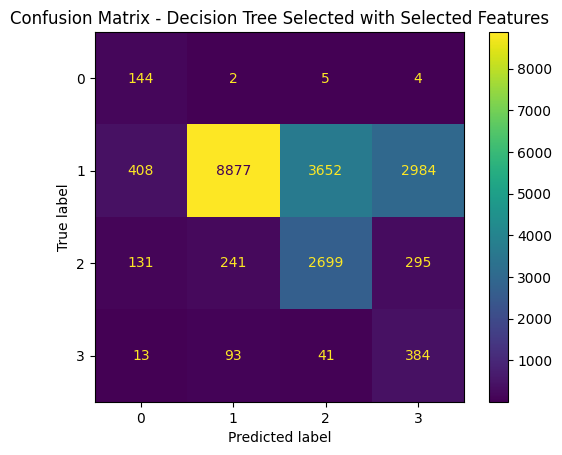

In [67]:
decision_tree_selected_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_selected)),
    ("classifier", DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_selected_results, decision_tree_selected_pred = evaluate_selected_model(
    model_name="Decision Tree Selected",
    model=decision_tree_selected_model,
    X_train=X_train_selected,
    X_test=X_test_selected,
    y_train=y_train_selected,
    y_test=y_test_selected
)

Training model with selected features: Random Forest Selected



Classification Report:
              precision    recall  f1-score   support

           1       0.24      0.94      0.38       155
           2       0.96      0.65      0.78     15921
           3       0.42      0.82      0.56      3366
           4       0.16      0.63      0.25       531

    accuracy                           0.68     19973
   macro avg       0.45      0.76      0.49     19973
weighted avg       0.84      0.68      0.72     19973


Confusion Matrix:
[[  146     0     4     5]
 [  332 10341  3683  1565]
 [  119   251  2747   249]
 [    7   151    37   336]]


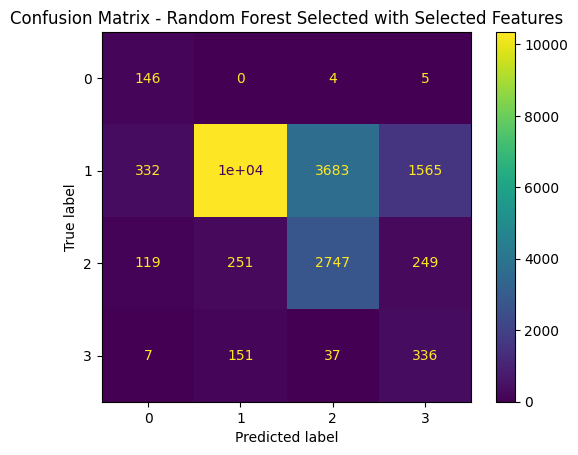

In [68]:
random_forest_selected_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_selected)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

random_forest_selected_results, random_forest_selected_pred = evaluate_selected_model(
    model_name="Random Forest Selected",
    model=random_forest_selected_model,
    X_train=X_train_selected,
    X_test=X_test_selected,
    y_train=y_train_selected,
    y_test=y_test_selected
)

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">۵.۳. مقایسه نهایی و اثر انتخاب ویژگی</h3>
</div>

In [69]:
all_results_final = [
    logistic_results,
    decision_tree_results,
    random_forest_results,
    logistic_selected_results,
    decision_tree_selected_results,
    random_forest_selected_results
]

final_results_df = pd.DataFrame(all_results_final)

final_results_df = final_results_df.sort_values(by="f1_macro", ascending=False)

final_results_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
5,Random Forest Selected,0.679417,0.446182,0.760081,0.492265,0.844860,0.679417,0.722053
2,Random Forest,0.675312,0.442861,0.753159,0.487159,0.843632,0.675312,0.718651
1,Decision Tree,0.603064,0.425760,0.754187,0.446579,0.844509,0.603064,0.660289
4,Decision Tree Selected,0.606018,0.424265,0.752901,0.445162,0.843549,0.606018,0.663739
0,Logistic Regression,0.414059,0.362083,0.625167,0.302931,0.820232,0.414059,0.481141
3,Logistic Regression Selected,0.411556,0.361474,0.626828,0.301718,0.819286,0.411556,0.478206


In [70]:
final_results_df.to_csv("final_model_comparison.csv", index=False)
original_importance_df.to_csv("feature_importance_random_forest.csv", index=False)

selected_features_df = pd.DataFrame({
    "selected_feature": selected_features
})

selected_features_df.to_csv("selected_features_top25.csv", index=False)

print("Final results saved successfully.")

Final results saved successfully.


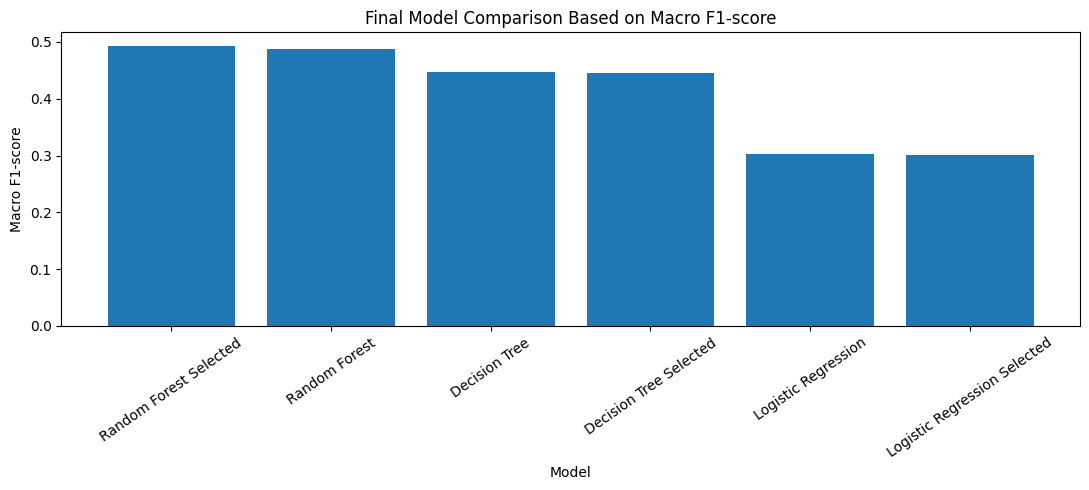

In [71]:
plt.figure(figsize=(11, 5))

plt.bar(final_results_df["model"], final_results_df["f1_macro"])

plt.title("Final Model Comparison Based on Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

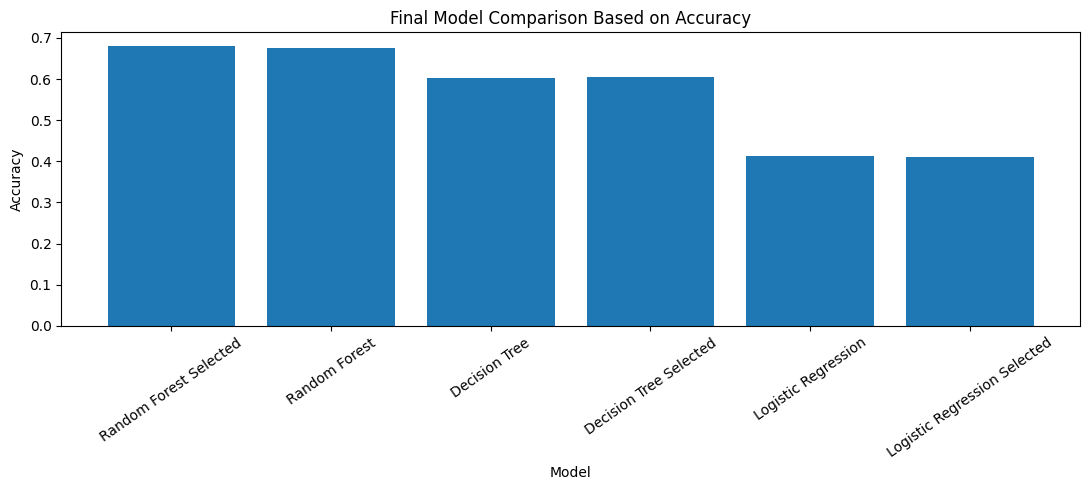

In [72]:
plt.figure(figsize=(11, 5))

plt.bar(final_results_df["model"], final_results_df["accuracy"])

plt.title("Final Model Comparison Based on Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="text-align: right;">
<h3 dir="rtl" style="text-align: right;">نتیجه انتخاب ویژگی</h3>
<p dir="rtl" style="text-align: right;">اهمیت ویژگی‌ها از Random Forest آموزش‌دیده روی بخش آموزش استخراج شد. اهمیت ستون‌های حاصل از One-Hot Encoding به ویژگی اصلی برگردانده و با هم جمع شد؛ سپس ۲۵ ویژگی با بیشترین اهمیت انتخاب شدند. بنابراین داده آزمون در تصمیم انتخاب ویژگی دخالت نداشته است.</p>
<p dir="rtl" style="text-align: right;">پس از آموزش دوباره سه مدل، Random Forest با ویژگی‌های منتخب به Accuracy برابر ۰٫۶۷۹۴، Macro F1-score برابر ۰٫۴۹۲۳ و Weighted F1-score برابر ۰٫۷۲۲۱ رسید. این مدل هم سقف ۲۵ ویژگی را رعایت می‌کند و هم نسبت به Random Forest اولیه اندکی بهتر است؛ به همین دلیل مدل نهایی پروژه در نظر گرفته شد.</p>
</div>

<div dir="rtl" align="right" style="text-align: right;">
<h2 dir="rtl" style="text-align: right;">۶. اجرای مدل روی داده تست</h2>
<p dir="rtl" style="text-align: right;">سلول زیر مدل نهایی را روی تمام داده آموزشی پاک‌سازی‌شده برازش می‌دهد و فایل مدل را ذخیره می‌کند. اگر فایل <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">group_28_test.csv</code> در کنار نوت‌بوک قرار داشته باشد، همان پیش‌پردازش روی آن اعمال و فایل <code dir="ltr" style="direction: ltr; unicode-bidi: embed;">group_28_test_predictions.csv</code> تولید می‌شود. در نبود فایل تست، سلول بدون خطا پایان می‌یابد و مسیر مورد انتظار را اعلام می‌کند.</p>
</div>

In [73]:
from pathlib import Path
import joblib


def prepare_external_features(raw_frame):
    """Apply the same deterministic raw-feature steps used for training."""
    features = raw_frame.drop(columns=[target_col], errors="ignore").copy()
    features = features.drop(columns=constant_cols, errors="ignore")

    if "f14" in features.columns:
        parsed_datetime = pd.to_datetime(features["f14"], errors="coerce")
        features["f14_year"] = parsed_datetime.dt.year
        features["f14_month"] = parsed_datetime.dt.month
        features["f14_day"] = parsed_datetime.dt.day
        features["f14_hour"] = parsed_datetime.dt.hour
        features["f14_dayofweek"] = parsed_datetime.dt.dayofweek
        features = features.drop(columns=["f14"])

    for col in features.select_dtypes(include=["bool"]).columns:
        features[col] = features[col].astype(int)

    features = features.drop(columns=high_cardinality_cats, errors="ignore")
    for col in selected_features:
        if col not in features.columns:
            features[col] = np.nan

    return features[selected_features]


final_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_selected)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

final_model.fit(X_selected, y)

model_bundle = {
    "model": final_model,
    "selected_features": selected_features,
    "constant_columns": constant_cols,
    "high_cardinality_columns": high_cardinality_cats,
    "target_column": target_col,
}
joblib.dump(model_bundle, "group_28_final_model.joblib")
print("Final model saved as group_28_final_model.joblib")

test_path = Path("group_28_test.csv")
if test_path.exists():
    external_test = pd.read_csv(test_path)
    external_features = prepare_external_features(external_test)
    external_predictions = final_model.predict(external_features)

    prediction_output = pd.DataFrame({target_col: external_predictions})
    prediction_output.to_csv("group_28_test_predictions.csv", index=False)
    print("Predictions saved as group_28_test_predictions.csv")

    if target_col in external_test.columns:
        print("\nExternal test classification report:")
        print(classification_report(
            external_test[target_col], external_predictions, zero_division=0
        ))
else:
    print("No external test file found. Place group_28_test.csv beside the notebook and rerun this cell.")

Final model saved as group_28_final_model.joblib
No external test file found. Place group_28_test.csv beside the notebook and rerun this cell.


<div dir="rtl" align="right" style="text-align: right;">
<h2 dir="rtl" style="text-align: right;">۷. جمع‌بندی</h2>
<p dir="rtl" style="text-align: right;">در این پروژه، داده اختصاصی گروه ۲۸ بدون استفاده از منبع خارجی تحلیل شد. پاک‌سازی و تبدیل‌ها در یک مسیر بازتولیدپذیر انجام شدند، سه مدل با معیارهای مناسب داده نامتوازن مقایسه شدند و محدودیت ۲۵ ویژگی رعایت شد. Random Forest با ویژگی‌های منتخب بهترین نتیجه را به دست آورد. Recall کلاس‌های کم‌تعداد نسبتاً بالا است، اما Precision این کلاس‌ها پایین‌تر باقی مانده؛ بنابراین نتیجه نشان‌دهنده یک مصالحه میان حساسیت به اقلیت‌ها و تعداد پیش‌بینی‌های مثبت کاذب است.</p>
<p dir="rtl" style="text-align: right;">فایل مدل و سلول اجرای داده تست در انتهای نوت‌بوک قرار دارد تا همان مسیر در روز ارائه بدون تغییر در منطق پروژه اجرا شود.</p>
</div>